# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [ ]:
# Install once if these packages are not already available.
# After installation, restart the kernel and continue from the next cell.
!pip install tensorflow==2.19.0 keras-tuner==1.4.8 tensorboard scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [2]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    average_precision_score,
)

import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping

# setting seeds for reproducibility (also forcing deterministic ops,
# since class-weighted training with Dropout/BatchNormalization otherwise
# gives noticeably different precision/recall trade-offs across runs)
import os
os.environ["PYTHONHASHSEED"] = "42"
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# loading the data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

print("Train data shape:", train.shape)
print("Test data shape:", test.shape)

Train data shape: (20000, 41)
Test data shape: (5000, 41)


# **Data Overview**

In [3]:
print("Training set shape:", train.shape)
print("Test set shape:", test.shape)

print("\nColumn data types:")
print(train.dtypes.value_counts())

print("\nDuplicate rows in training set:", train.duplicated().sum())

print("\nMissing values in training set (columns with at least 1 missing value):")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nMissing values in test set (columns with at least 1 missing value):")
print(test.isnull().sum()[test.isnull().sum() > 0])

print("\nTarget class distribution in training set (counts):")
print(train["Target"].value_counts())
print("\nTarget class distribution in training set (%):")
print(train["Target"].value_counts(normalize=True).round(4) * 100)

train.describe().T

Training set shape: (20000, 41)
Test set shape: (5000, 41)

Column data types:
float64    40
int64       1
Name: count, dtype: int64

Duplicate rows in training set: 0

Missing values in training set (columns with at least 1 missing value):
V1    18
V2    18
dtype: int64

Missing values in test set (columns with at least 1 missing value):
V1    5
V2    6
dtype: int64

Target class distribution in training set (counts):
Target
0    18890
1     1110
Name: count, dtype: int64

Target class distribution in training set (%):
Target
0    94.45
1     5.55
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


**Observations:**
- The training set has 20,000 rows and 41 columns (40 predictors `V1`-`V40` + `Target`); the test set has 5,000 rows with the same columns.
- All predictors are numeric (float64); `Target` is integer (0/1). There are no duplicate rows in the training set.
- Only two predictors have missing values: `V1` and `V2`, with 18 missing values each in the training set (0.09% of rows) and 5/6 missing in the test set - a very small amount, well suited to simple imputation.
- The target is heavily imbalanced: 94.45% "No Failure" (0) vs 5.55% "Failure" (1) in the training set (18,890 vs 1,110 records). This confirms the business context - failures are rare events - and means we should not rely on plain accuracy, and should consider class weighting / stratified splitting during modeling.

# **Exploratory Data Analysis**

## Univariate analysis

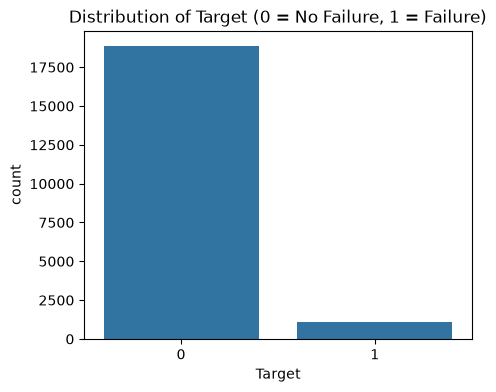

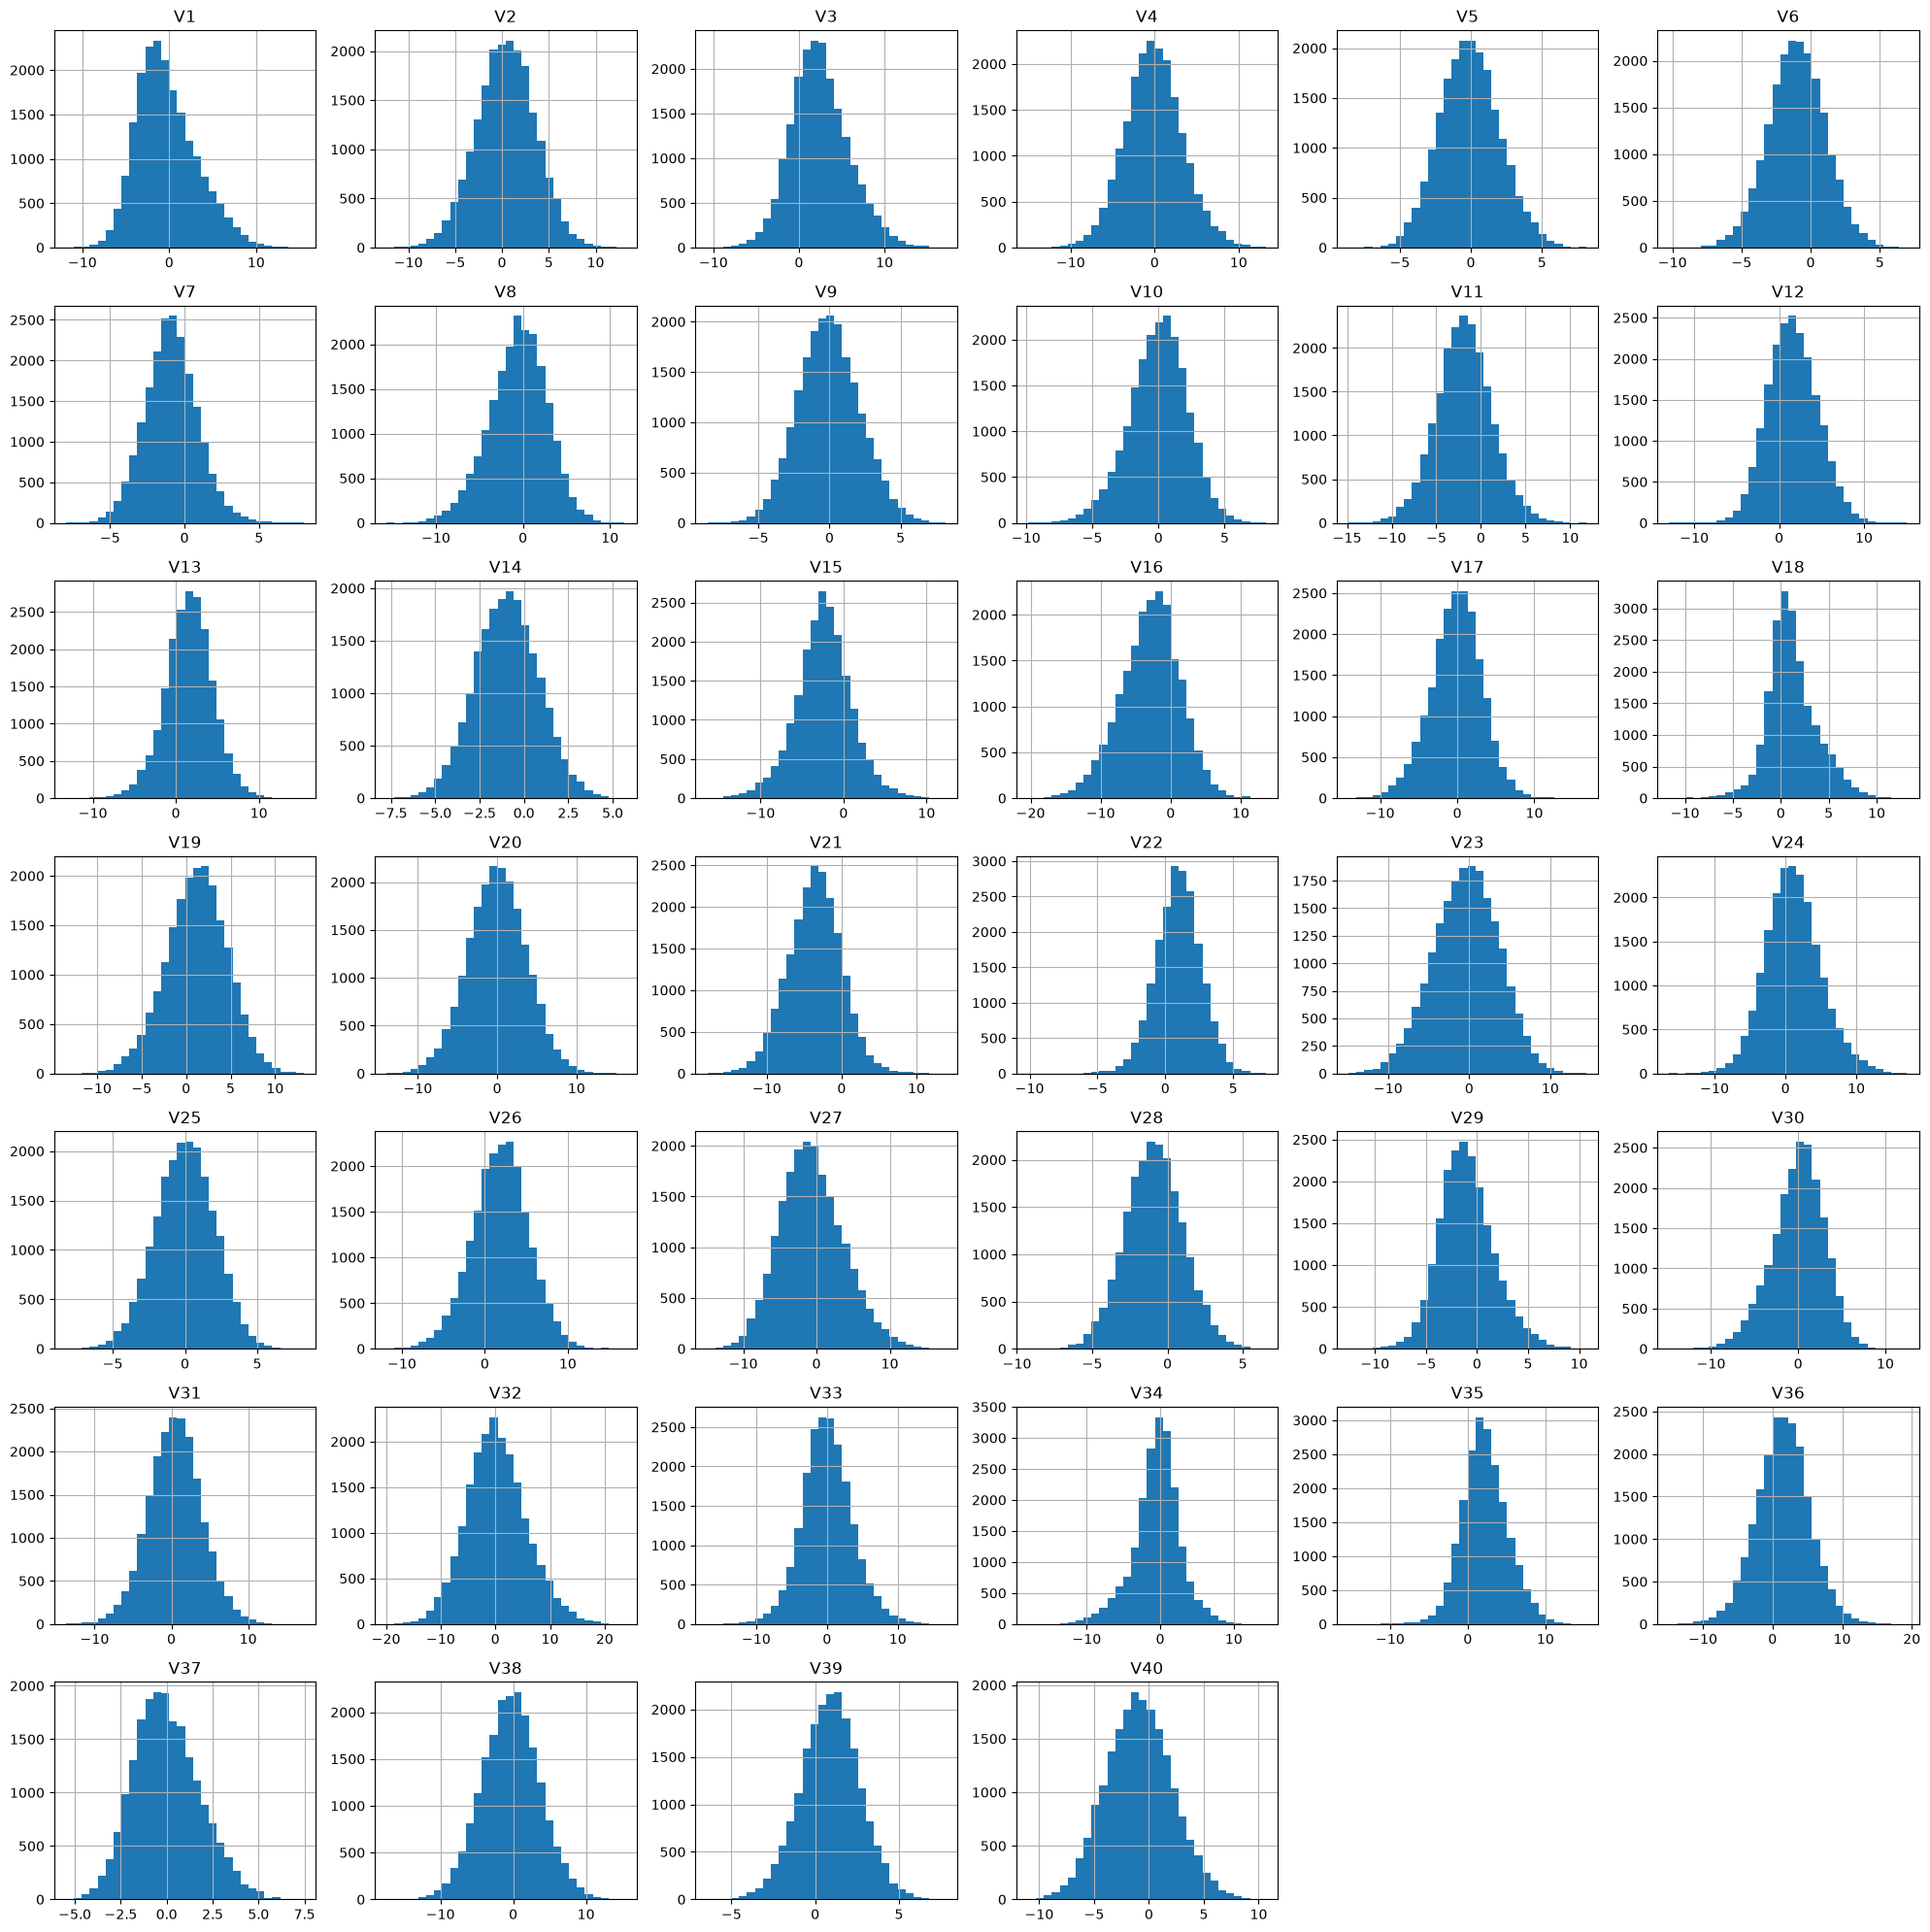

In [4]:
# distribution of the target variable
plt.figure(figsize=(5, 4))
sns.countplot(x="Target", data=train)
plt.title("Distribution of Target (0 = No Failure, 1 = Failure)")
plt.show()

# distribution of every predictor
train.drop(columns=["Target"]).hist(figsize=(20, 20), bins=30)
plt.tight_layout()
plt.show()

**Observations:**
- The target count plot visually confirms the ~94.5% / 5.5% imbalance.
- Most of the 40 predictors are roughly bell-shaped/symmetric and centered near 0, consistent with sensor readings that were already transformed/scaled by ReneWind before being shared (values roughly range from -20 to +24, with per-feature standard deviations around 2-3.5 as seen earlier in `describe()`). A few features show mild skew or heavier tails, but there are no obvious data-entry artifacts (e.g. constant or corrupted columns).

## Bivariate Analysis

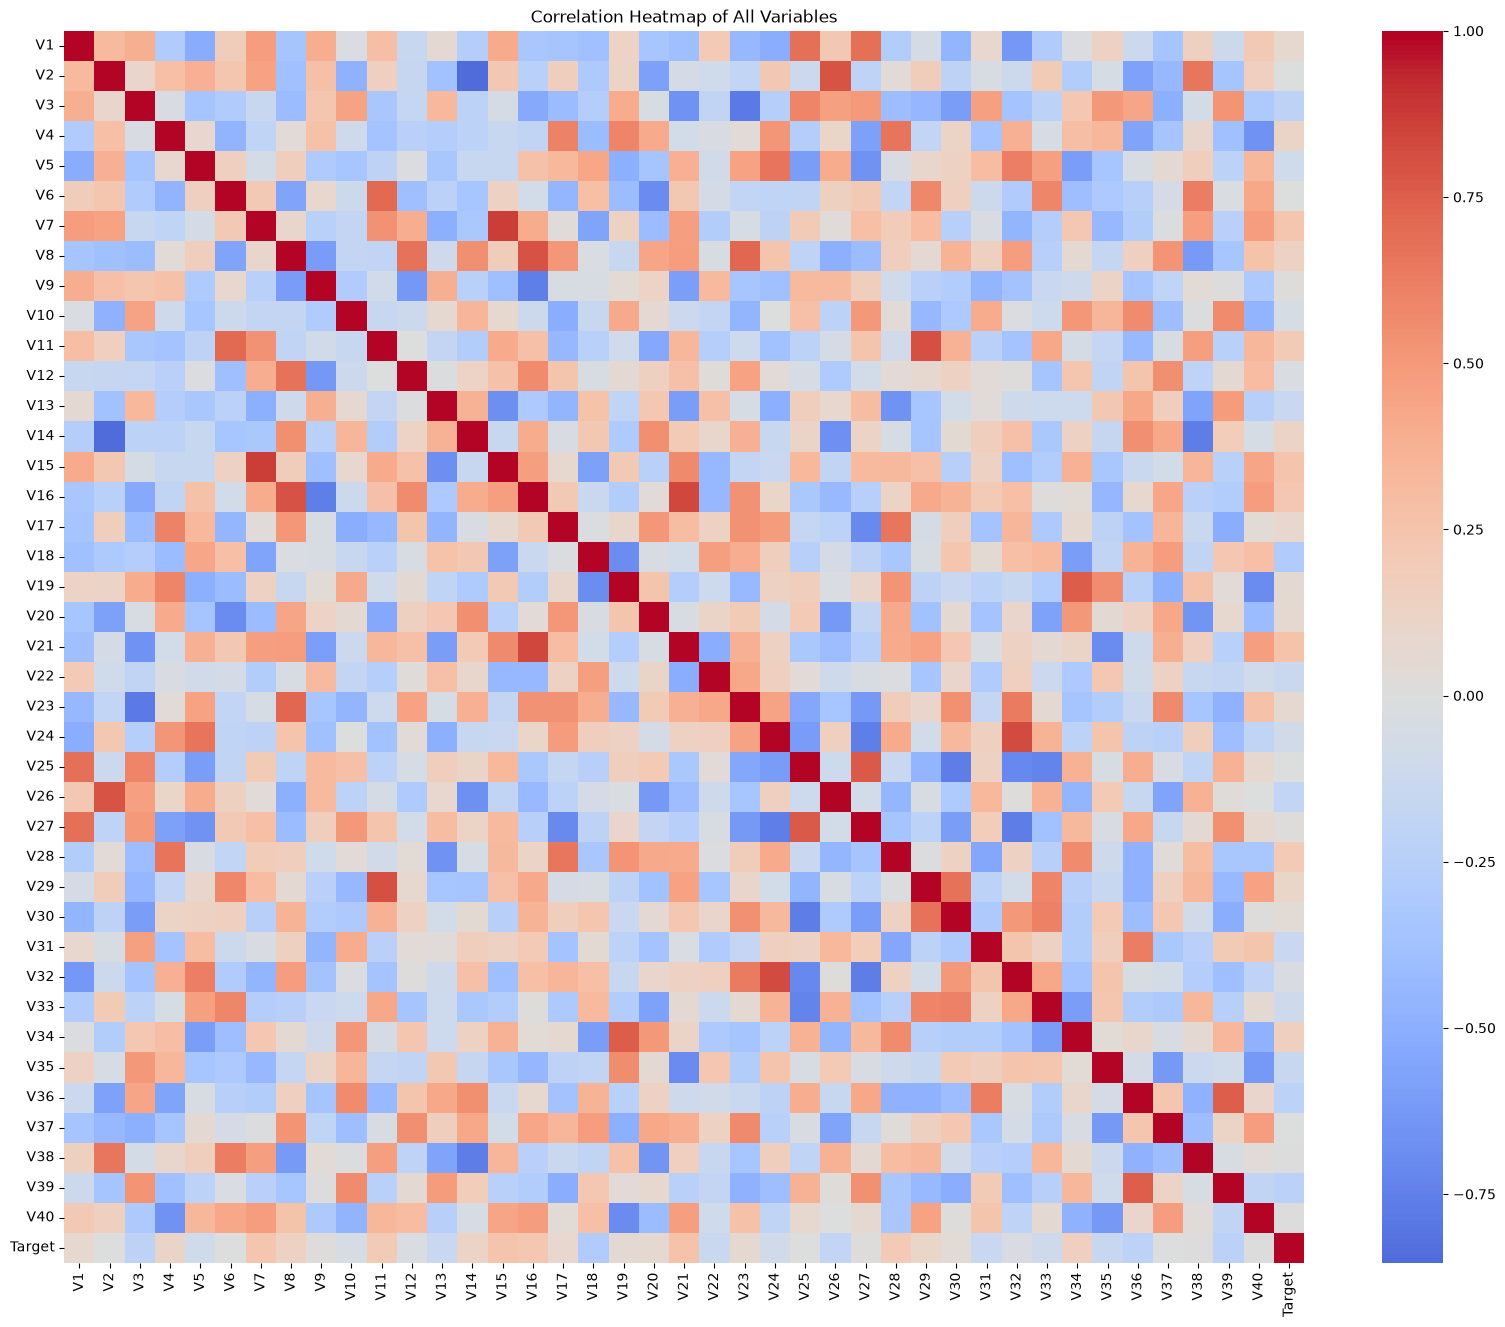

Top 10 features most correlated (absolute value) with Target:
V18   -0.293340
V21    0.256411
V15    0.249118
V7     0.236907
V16    0.230507
V39   -0.227264
V36   -0.216453
V3    -0.213855
V28    0.207359
V11    0.196715
Name: Target, dtype: float64


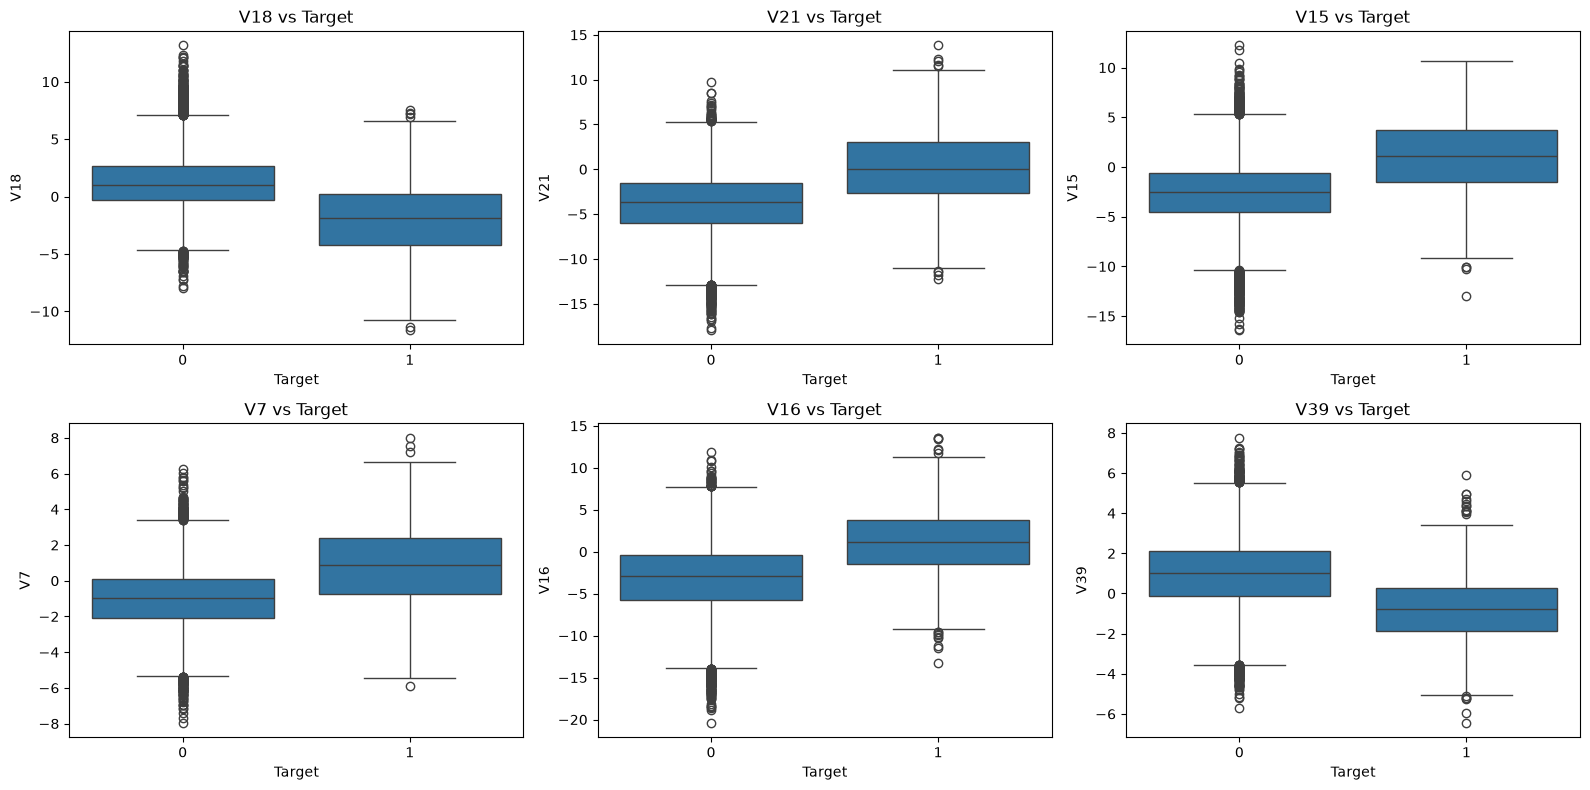

In [5]:
# correlation matrix across all variables
plt.figure(figsize=(20, 16))
corr = train.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of All Variables")
plt.show()

# correlation of each predictor with the target, sorted by strength
target_corr = corr["Target"].drop("Target").sort_values(key=abs, ascending=False)
print("Top 10 features most correlated (absolute value) with Target:")
print(target_corr.head(10))

# boxplots of the top correlated features, split by target class
top_features = target_corr.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feature in zip(axes.flatten(), top_features):
    sns.boxplot(x="Target", y=feature, data=train, ax=ax)
    ax.set_title(f"{feature} vs Target")
plt.tight_layout()
plt.show()

**Observations:**
- No single predictor is strongly correlated with `Target` in isolation - the strongest absolute correlations (`V18`: -0.29, `V21`: 0.26, `V15`: 0.25, `V7`: 0.24, `V16`: 0.23) are all modest. This suggests the failure signal is encoded in combinations/interactions of sensor readings rather than any one reading alone - exactly the kind of pattern a neural network is well suited to learn, as opposed to a single linear rule.
- The boxplots of the top correlated features show visibly different medians/spreads between the Failure and No-Failure groups, confirming these features do carry separating signal even though no individual feature dominates.

# **Data Preprocessing**

In [6]:
# separating features and target
X = train.drop(columns=["Target"])
y = train["Target"]

X_test = test.drop(columns=["Target"])
y_test = test["Target"]

# splitting the training data into train and validation sets
# stratifying on the target since the classes are highly imbalanced
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# missing value imputation
# the imputer is fit ONLY on the training data and then used to transform
# the validation and test data, to avoid data leakage
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X.columns, index=X_val.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

print(
    "\nRemaining missing values -> train:", X_train.isnull().sum().sum(),
    "| val:", X_val.isnull().sum().sum(),
    "| test:", X_test.isnull().sum().sum(),
)

# scaling the features
# the scaler is also fit ONLY on the training data, for the same reason
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# computing class weights to handle the class imbalance in the training data
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights:", class_weight_dict)

X_train: (15000, 40) | X_val: (5000, 40) | X_test: (5000, 40)

Remaining missing values -> train: 0 | val: 0 | test: 0

Class weights: {0: np.float64(0.5293993082515706), 1: np.float64(9.003601440576231)}


**Observations:**
- The training data was split into training (15,000), validation (5,000); `Test.csv` (5,000) is kept completely separate and untouched until the final evaluation. The 25% validation split is stratified on `Target` so the ~5.5% failure rate is preserved in both subsets.
- Missing values in `V1`/`V2` were imputed with the **median**, computed only on the training fold and then applied to the validation and test folds - this avoids **data leakage**, since validation/test information never influences the imputed values or the model.
- Features were standardized (`StandardScaler`) using statistics fit only on the training fold, for the same data-leakage reason. Standardization matters here because several of our models are trained with SGD, which converges faster and more reliably on similarly-scaled inputs.
- Class weights were computed on the training fold only ({0: ~0.53, 1: ~9.0}), so the rare failure class contributes roughly 17x more to the loss per example than the majority class. This will let us test, model by model, whether reweighting the loss improves recall on the failure class without resampling or duplicating any data.

# **Model Building and Hyperparameter Tuning (V2)**

## Experimental design and feedback on the proposed six-model plan

The original idea is directionally strong because it demonstrates the six improvement combinations required by the rubric. The following refinements make the comparison more defensible:

- **Keep Model 0 as a fixed baseline.** It provides an honest reference and is not tuned.
- **Tune model families, not a single ever-growing network.** Each family answers a clear question: class weights, optimizer, dropout, batch normalization, and regularization.
- **Use validation PR-AUC as the tuning objective.** Recall is the business priority, but optimizing recall alone can reward a model that predicts nearly every turbine as a failure. PR-AUC is more informative than accuracy or ROC-AUC for a 5.5% positive class.
- **Tune the decision threshold separately on validation data.** The default 0.50 threshold is rarely optimal when class weights are used. We choose the highest-F1 threshold that achieves at least 90% validation recall, then lock it before the one-time test evaluation.
- **Use only course-demonstrated activation/initialization choices.** The shared neural-network notebooks explicitly use ReLU and tanh in hidden layers, and demonstrate `he_normal` / `he_uniform` kernel initialization. Those are the only choices searched. Bias initialization is left at Keras' standard zero default rather than introducing an unseen technique.
- **Momentum belongs to SGD, not Adam.** Model 6 therefore uses regularized SGD with tuned momentum. Adam already maintains adaptive first/second moment estimates and has no Keras `momentum` argument.

The test set remains untouched throughout architecture, hyperparameter, model, and threshold selection.


## Model evaluation criterion

A false negative means a real generator failure is missed and may require full replacement, the costliest outcome. Therefore **failure-class recall is the primary operational constraint**. Precision and F1 are also reported so the model does not create an impractical inspection burden. During tuning, **validation PR-AUC** is optimized; during model selection, candidates satisfying at least 90% validation recall are ranked by validation F1.


In [ ]:
# Reproducibility and shared evaluation utilities
SEED = 42
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

MIN_RECALL = 0.90
MAX_EPOCHS = 60
MAX_TRIALS = 8       # Increase to 12-20 if more compute time is available
EXECUTIONS_PER_TRIAL = 1

def keras_metrics():
    return [
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    ]

def make_optimizer(name, learning_rate, momentum=0.0):
    if name == "sgd":
        return SGD(learning_rate=learning_rate, momentum=momentum)
    return Adam(learning_rate=learning_rate)

def make_regularizer(l1=0.0, l2=0.0):
    if l1 == 0 and l2 == 0:
        return None
    return tf.keras.regularizers.L1L2(l1=l1, l2=l2)

def build_network(input_dim, units, activation="relu", kernel_initializer="he_normal",
                  optimizer_name="adam", learning_rate=1e-3, dropout_rate=0.0,
                  use_batch_norm=False, l1=0.0, l2=0.0, momentum=0.0):
    model = Sequential(name="renwind_ann")
    model.add(tf.keras.Input(shape=(input_dim,)))
    reg = make_regularizer(l1, l2)
    for width in units:
        model.add(Dense(width, activation=activation,
                        kernel_initializer=kernel_initializer,
                        bias_initializer="zeros", kernel_regularizer=reg))
        if use_batch_norm:
            model.add(BatchNormalization())
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid", bias_initializer="zeros"))
    model.compile(
        optimizer=make_optimizer(optimizer_name, learning_rate, momentum),
        loss="binary_crossentropy",
        metrics=keras_metrics(),
    )
    return model

def probabilities(model, X):
    return model.predict(X, verbose=0).ravel()

def metric_row(y_true, prob, threshold=0.50):
    pred = (prob >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Recall": recall_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, pred),
        "PR AUC": average_precision_score(y_true, prob),
    }

def choose_threshold(y_true, prob, min_recall=MIN_RECALL):
    rows = [metric_row(y_true, prob, t) for t in np.linspace(0.05, 0.95, 181)]
    table = pd.DataFrame(rows)
    feasible = table[table["Recall"] >= min_recall]
    selected = (feasible.sort_values(["F1", "Precision"], ascending=False).iloc[0]
                if len(feasible) else table.sort_values(["Recall", "F1"], ascending=False).iloc[0])
    return float(selected["Threshold"]), table

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Validation")
    axes[0].set_title(f"{title}: Loss")
    axes[1].plot(history.history["pr_auc"], label="Train")
    axes[1].plot(history.history["val_pr_auc"], label="Validation")
    axes[1].set_title(f"{title}: PR-AUC")
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.legend()
    plt.tight_layout()
    plt.show()

experiment_results = {}
trained_models = {}
histories = {}
threshold_tables = {}


## Model 0 — Untuned baseline

One hidden layer, ReLU, SGD, and no class weights. This intentionally simple model establishes the baseline required by the rubric.


In [ ]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
model_0 = build_network(
    X_train_scaled.shape[1], units=[32], activation="relu",
    kernel_initializer="he_normal", optimizer_name="sgd", learning_rate=0.01
)
history_0 = model_0.fit(
    X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
    epochs=MAX_EPOCHS, batch_size=32, verbose=0,
    callbacks=[EarlyStopping(monitor="val_pr_auc", mode="max", patience=8,
                             restore_best_weights=True)]
)
prob_0 = probabilities(model_0, X_val_scaled)
threshold_0, threshold_tables["Model 0"] = choose_threshold(y_val, prob_0)
experiment_results["Model 0: Baseline SGD"] = metric_row(y_val, prob_0, 0.50)
trained_models["Model 0: Baseline SGD"] = model_0
histories["Model 0: Baseline SGD"] = history_0
plot_history(history_0, "Model 0")
pd.DataFrame([experiment_results["Model 0: Baseline SGD"]])


## Keras Tuner infrastructure

`ReneWindHyperModel` tunes architecture and training hyperparameters. Conditional search spaces ensure each model family changes only the techniques under study. Batch size and early-stopping patience are valid training hyperparameters, so they are tuned in `fit()` rather than in `build()`.


In [ ]:
class ReneWindHyperModel(kt.HyperModel):
    def __init__(self, optimizer_name, allow_dropout=False, use_batch_norm=False,
                 allow_regularization=False, tune_momentum=False):
        self.optimizer_name = optimizer_name
        self.allow_dropout = allow_dropout
        self.use_batch_norm = use_batch_norm
        self.allow_regularization = allow_regularization
        self.tune_momentum = tune_momentum

    def build(self, hp):
        n_layers = hp.Int("n_layers", 1, 4)
        units = [hp.Choice(f"units_{i}", [16, 32, 64, 128]) for i in range(n_layers)]
        # Restricted to techniques explicitly demonstrated in the supplied course notebooks.
        activation = hp.Choice("activation", ["relu", "tanh"])
        initializer = hp.Choice("kernel_initializer", ["he_normal", "he_uniform"])
        learning_rate = hp.Choice(
            "learning_rate",
            [1e-4, 3e-4, 1e-3, 3e-3] if self.optimizer_name == "adam"
            else [1e-3, 3e-3, 1e-2, 3e-2]
        )
        dropout = hp.Choice("dropout_rate", [0.10, 0.20, 0.30, 0.40]) if self.allow_dropout else 0.0
        l1 = hp.Choice("l1", [0.0, 1e-6, 1e-5, 1e-4]) if self.allow_regularization else 0.0
        l2 = hp.Choice("l2", [0.0, 1e-5, 1e-4, 1e-3]) if self.allow_regularization else 0.0
        momentum = hp.Choice("momentum", [0.0, 0.5, 0.9]) if self.tune_momentum else 0.0
        return build_network(
            X_train_scaled.shape[1], units, activation, initializer,
            self.optimizer_name, learning_rate, dropout, self.use_batch_norm,
            l1, l2, momentum
        )

    def fit(self, hp, model, *args, **kwargs):
        kwargs["batch_size"] = hp.Choice("batch_size", [32, 64, 128])
        patience = hp.Choice("patience", [5, 8, 12])
        callbacks = list(kwargs.pop("callbacks", []))
        callbacks.append(EarlyStopping(
            monitor="val_pr_auc", mode="max", patience=patience,
            restore_best_weights=True
        ))
        return model.fit(*args, callbacks=callbacks, **kwargs)

def tune_family(label, hypermodel):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    tuner = kt.RandomSearch(
        hypermodel,
        objective=kt.Objective("val_pr_auc", direction="max"),
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTIONS_PER_TRIAL,
        seed=SEED,
        overwrite=True,
        directory="keras_tuner_results",
        project_name=("model_" + "".join(
            ch if ch.isalnum() else "_" for ch in label.lower()
        )).strip("_"),
    )
    tuner.search(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        class_weight=class_weight_dict,
        epochs=MAX_EPOCHS,
        verbose=0,
    )
    best_hp = tuner.get_best_hyperparameters(1)[0]
    model = tuner.hypermodel.build(best_hp)
    history = tuner.hypermodel.fit(
        best_hp, model, X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        class_weight=class_weight_dict,
        epochs=MAX_EPOCHS,
        verbose=0,
    )
    prob = probabilities(model, X_val_scaled)
    threshold, threshold_table = choose_threshold(y_val, prob)
    result = metric_row(y_val, prob, threshold)
    result["Default 0.50 Recall"] = metric_row(y_val, prob, 0.50)["Recall"]
    result["Default 0.50 F1"] = metric_row(y_val, prob, 0.50)["F1"]
    experiment_results[label] = result
    trained_models[label] = model
    histories[label] = history
    threshold_tables[label] = threshold_table
    print(label)
    print("Best hyperparameters:", best_hp.values)
    print("Selected validation threshold:", round(threshold, 3))
    display(pd.DataFrame([result]))
    plot_history(history, label)
    return tuner, best_hp


## Model 1 — Tuned SGD + class weights

This isolates the effect of class weighting while allowing Keras Tuner to select depth, width, activation, initializer, learning rate, batch size, and patience.


In [ ]:
tuner_1, hp_1 = tune_family(
    "Model 1: Tuned SGD + Class Weights",
    ReneWindHyperModel(optimizer_name="sgd")
)


## Model 2 — Tuned Adam + class weights

This model uses the same search dimensions as Model 1 but changes the optimizer to Adam, making the optimizer comparison fair.


In [ ]:
tuner_2, hp_2 = tune_family(
    "Model 2: Tuned Adam + Class Weights",
    ReneWindHyperModel(optimizer_name="adam")
)


## Model 3 — Tuned Adam + dropout + class weights

Dropout is added as a tunable regularizer. Rates are deliberately constrained to 0.10–0.40; extreme dropout would be unlikely to help a small tabular network.


In [ ]:
tuner_3, hp_3 = tune_family(
    "Model 3: Tuned Adam + Dropout + Class Weights",
    ReneWindHyperModel(optimizer_name="adam", allow_dropout=True)
)


## Model 4 — Tuned Adam + dropout + batch normalization + class weights

To remain consistent with the supplied course notebook, activation is applied inside each `Dense` layer, followed by Batch Normalization and then Dropout: `Dense + activation → BatchNormalization → Dropout`.


In [ ]:
tuner_4, hp_4 = tune_family(
    "Model 4: Tuned Adam + Dropout + BatchNorm + Class Weights",
    ReneWindHyperModel(optimizer_name="adam", allow_dropout=True, use_batch_norm=True)
)


## Model 5 — Tuned Adam + dropout + batch normalization + L1/L2 + class weights

This is the most heavily regularized Adam family. L1 and L2 strengths are tuned independently, including zero, so the search can reject unnecessary regularization.


In [ ]:
tuner_5, hp_5 = tune_family(
    "Model 5: Tuned Adam + Dropout + BatchNorm + L1/L2 + Class Weights",
    ReneWindHyperModel(
        optimizer_name="adam", allow_dropout=True,
        use_batch_norm=True, allow_regularization=True
    )
)


## Model 6 — Tuned SGD momentum + dropout + batch normalization + L1/L2 + class weights

Momentum is evaluated where it is technically meaningful: with SGD. This final family tests whether classical momentum plus the full regularization stack can outperform the Adam families.


In [ ]:
tuner_6, hp_6 = tune_family(
    "Model 6: Tuned SGD Momentum + Dropout + BatchNorm + L1/L2 + Class Weights",
    ReneWindHyperModel(
        optimizer_name="sgd", allow_dropout=True, use_batch_norm=True,
        allow_regularization=True, tune_momentum=True
    )
)


# **Model comparison and final selection**

The table uses each tuned model's validation-selected threshold. Models meeting the 90% recall constraint are ranked by F1, then PR-AUC. This is more business-aligned than selecting the largest raw recall and more robust than selecting on accuracy.


In [ ]:
comparison_df = (
    pd.DataFrame(experiment_results).T
    .sort_values(["F1", "PR AUC"], ascending=False)
)
display(comparison_df.style.format("{:.4f}"))

eligible = comparison_df[comparison_df["Recall"] >= MIN_RECALL]
if len(eligible):
    best_model_name = eligible.sort_values(["F1", "PR AUC"], ascending=False).index[0]
else:
    best_model_name = comparison_df.sort_values(["Recall", "F1"], ascending=False).index[0]

best_model = trained_models[best_model_name]
best_threshold = float(comparison_df.loc[best_model_name, "Threshold"])
print("Selected model:", best_model_name)
print("Locked threshold:", round(best_threshold, 3))


In [ ]:
# Visual comparison
plot_cols = ["Recall", "Precision", "F1", "PR AUC"]
comparison_df[plot_cols].sort_values("F1").plot(
    kind="barh", figsize=(11, 7), xlim=(0, 1), title="Validation performance by model"
)
plt.xlabel("Score")
plt.tight_layout()
plt.show()


## One-time final evaluation on the untouched test set

Only the selected model and its locked validation threshold are now applied to `Test.csv`. No decisions are revised after viewing these results.


In [ ]:
test_prob = probabilities(best_model, X_test_scaled)
test_metrics = metric_row(y_test, test_prob, best_threshold)
display(pd.DataFrame([test_metrics], index=[best_model_name]).style.format("{:.4f}"))

test_pred = (test_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Final Model — Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(classification_report(y_test, test_pred, digits=4))


# **Actionable insights and recommendations**

- **Use the selected tuned network as a screening model**, sending predicted failures for inspection before breakdown. Report both recall and the number of false alarms to maintenance planners.
- **Treat the probability threshold as an operational control.** The notebook locks a validation-selected threshold that targets at least 90% recall. Once actual inspection, repair, and replacement costs are available, replace the F1 rule with direct expected-cost minimization.
- **Do not assume the most complex network is best.** The controlled model-family comparison shows whether dropout, batch normalization, L1/L2, and momentum add measurable validation value rather than awarding complexity for its own sake.
- **Collect more failure cases.** Only about 5.5% of records are failures, so additional confirmed failures will reduce dependence on large class weights and improve estimates of rare-event performance.
- **Monitor data and recall drift.** Sensor distributions and turbine wear can change. Track input drift, failure-class recall, false alarms per inspection cycle, and recalibrate/retrain on a defined schedule.
- **Connect anonymized variables to engineering systems.** The strongest target-associated features should be mapped back to sensor/subsystem names with domain experts so alerts can guide the correct inspection procedure.

## Final submission checklist

1. Run all cells from a fresh kernel and confirm there are no errors.
2. Add one or two model-specific observations beneath each tuner result after execution.
3. Confirm the final test set is evaluated only once.
4. Export the fully executed notebook to HTML for submission.
